## EQ算法 ##
**原始图像**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline

# 全局中文字体配置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

#为了模拟py里面用大量的N但实际里面N会变小
fs = 44100
N = 8192*2

t = np.arange(N) / fs
np.random.seed(250)
audio_frame = np.random.randn(N)
# 窗函数
window = blackmanharris(N)
audio_frame *= window

# FFT
fft_res = fft.rfft(audio_frame)

freqs = fft.rfftfreq(N, 1/fs)

# 幅度
amp = np.abs(fft_res)

# 归一化
amp /= np.max(amp)

# dB
db = 20*np.log10(amp + 1e-12)

# 平滑插值
x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)

spline = make_interp_spline(freqs[1:], db[1:], k=3)
y_smooth = spline(x_smooth)

plt.figure(figsize=(12,6))

plt.semilogx(x_smooth, y_smooth, linewidth=2)

plt.title("Spectrum Analyzer")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")

plt.xlim(20, 20000)
plt.ylim(-80, 5)
plt.grid(True, which='both', alpha=0.3)

plt.show()

**peakfiltering**

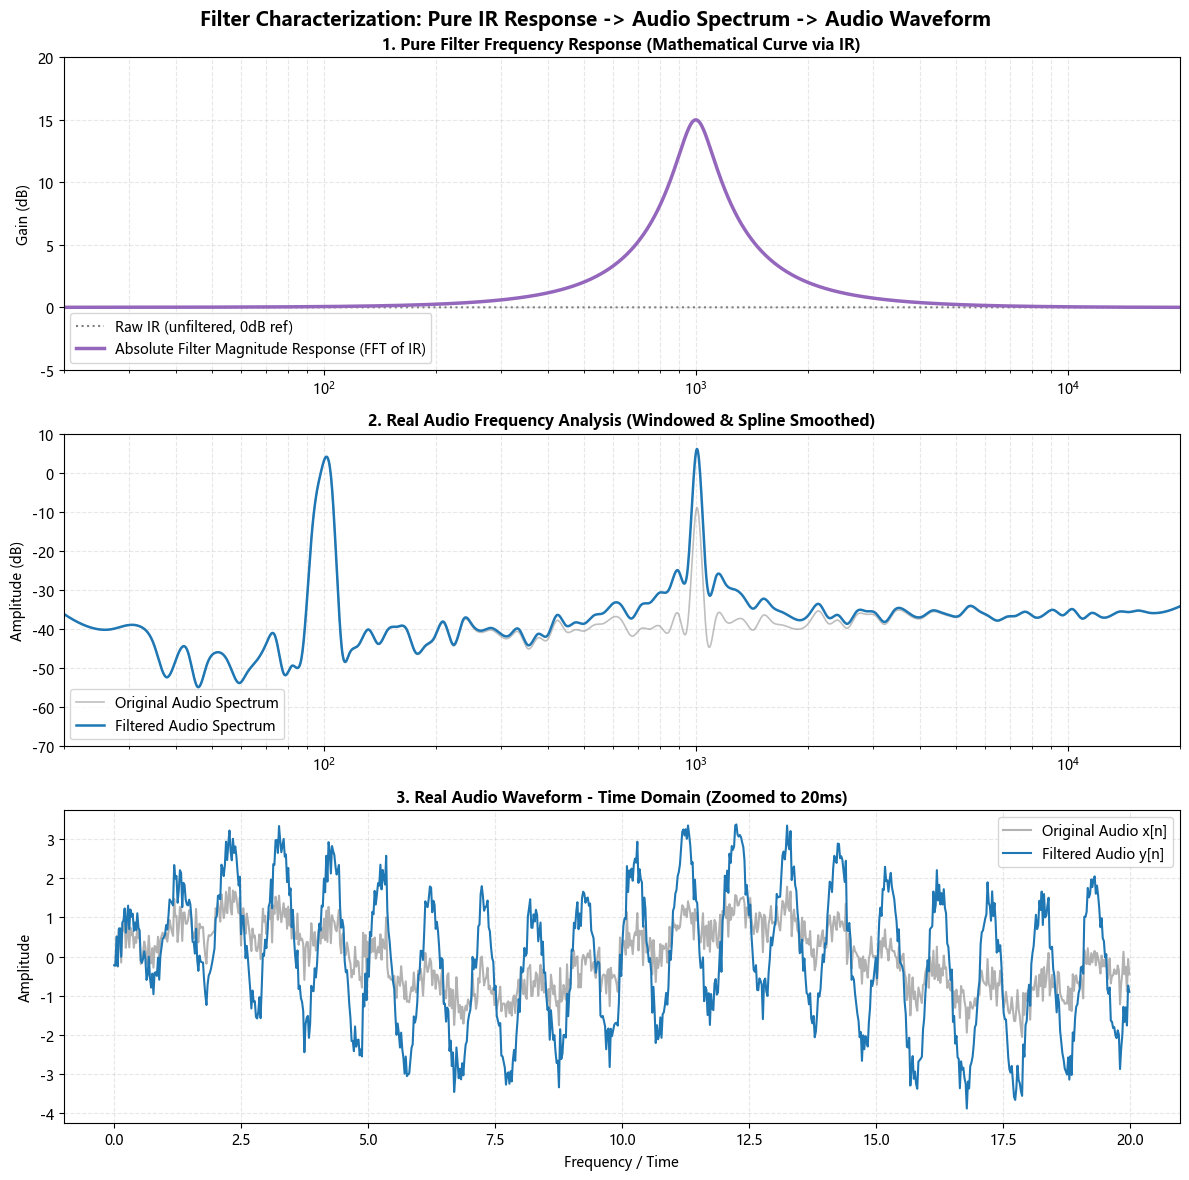

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft as fft
from scipy.signal import lfilter
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline

# EQ滤波函数
def peaking_eq_coefficients(f0, Q, gain_db, fs):
    A = 10 ** (gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    b0, b1, b2 = 1 + alpha * A, -2 * np.cos(w0), 1 - alpha * A
    a0, a1, a2 = 1 + alpha / A, -2 * np.cos(w0), 1 - alpha / A
    return [b0/a0, b1/a0, b2/a0], [1, a1/a0, a2/a0]

# 对数空间样条插值平滑
def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins)-1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i+1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)


fs = 44100
N = 8192 * 2  

# 计算 EQ
b, a = peaking_eq_coefficients(f0=1000, Q=2.0, gain_db=15, fs=fs)

# 生成原始音频帧与时间轴
t = np.arange(N) / fs
np.random.seed(250)
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)

# 生成标准冲激信号 (用来产生 IR)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0


# 4. 数字滤波模拟：执行时域差分方程

audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  # 时域脉冲响应 (IR)


# 5. FFT 变换与分贝转换

window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1/fs)

#加窗 -> FFT -> 归一化dB
fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
norm_val = np.max(np.abs(fft_audio_in))

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / norm_val + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / norm_val + 1e-12)

#IR直接纯 FFT 拿到滤波器频响绝对几何曲线（不加窗）
fft_ir = fft.rfft(impulse_filtered)
db_ir = 20 * np.log10(np.abs(fft_ir) + 1e-12)

# 原始 IR (未滤波) FFT — 理论 0dB 平坦参考线
fft_ir_raw = fft.rfft(impulse_raw)
db_ir_raw = 20 * np.log10(np.abs(fft_ir_raw) + 1e-12)


# 对数空间样条插值平滑

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)

# 音频频谱平滑
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth, num_bins=120)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth, num_bins=120)

# IR直接进行全局标准对数插值
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)

# 原始 IR 平滑
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

#绘图：按照 IR 频域 -> 真实音频频域 -> 真实音频时域 顺序排列

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("Filter Characterization: Pure IR Response -> Audio Spectrum -> Audio Waveform", 
             fontsize=14, fontweight='bold')

# --- 冲激响应IR的纯频域绝对响应 ---
ax1.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle=':', label='Raw IR (unfiltered, 0dB ref)')
ax1.semilogx(x_smooth, y_smooth_ir, color='tab:purple', linewidth=2.5, label='Absolute Filter Magnitude Response (FFT of IR)')
ax1.set_title("1. Pure Filter Frequency Response (Mathematical Curve via IR)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Gain (dB)")
ax1.set_xlim(20, 20000)
ax1.set_ylim(-5, 20)  # 聚焦展示 0dB 到 15dB Peak 提升
ax1.grid(True, which='both', alpha=0.3, linestyle='--')
ax1.legend(loc='lower left')

# --- 图二：真实音频流加窗平滑后的频域图 ---
ax2.semilogx(x_smooth, y_smooth_audio_in, color='gray', alpha=0.5, linewidth=1.2, label='Original Audio Spectrum')
ax2.semilogx(x_smooth, y_smooth_audio_out, color='tab:blue', linewidth=1.8, label='Filtered Audio Spectrum')
ax2.set_title("2. Real Audio Frequency Analysis (Windowed & Spline Smoothed)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Amplitude (dB)")
ax2.set_xlim(20, 20000)
ax2.set_ylim(-70, 10)
ax2.grid(True, which='both', alpha=0.3, linestyle='--')
ax2.legend(loc='lower left')

# --- 图三：真实音频的时域波形对比 ---
time_zoom = int(fs * 0.02)  # 放大查看前 20ms
ax3.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='gray', alpha=0.6, label='Original Audio x[n]')
ax3.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='tab:blue', linewidth=1.5, label='Filtered Audio y[n]')
ax3.set_title("3. Real Audio Waveform - Time Domain (Zoomed to 20ms)", fontsize=11, fontweight='bold')
ax3.set_xlabel("Frequency / Time")  # 保持 X 轴底层标注习惯
ax3.set_ylabel("Amplitude")
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(loc='upper right')

plt.tight_layout()
plt.show()

**High Shelf EQ**


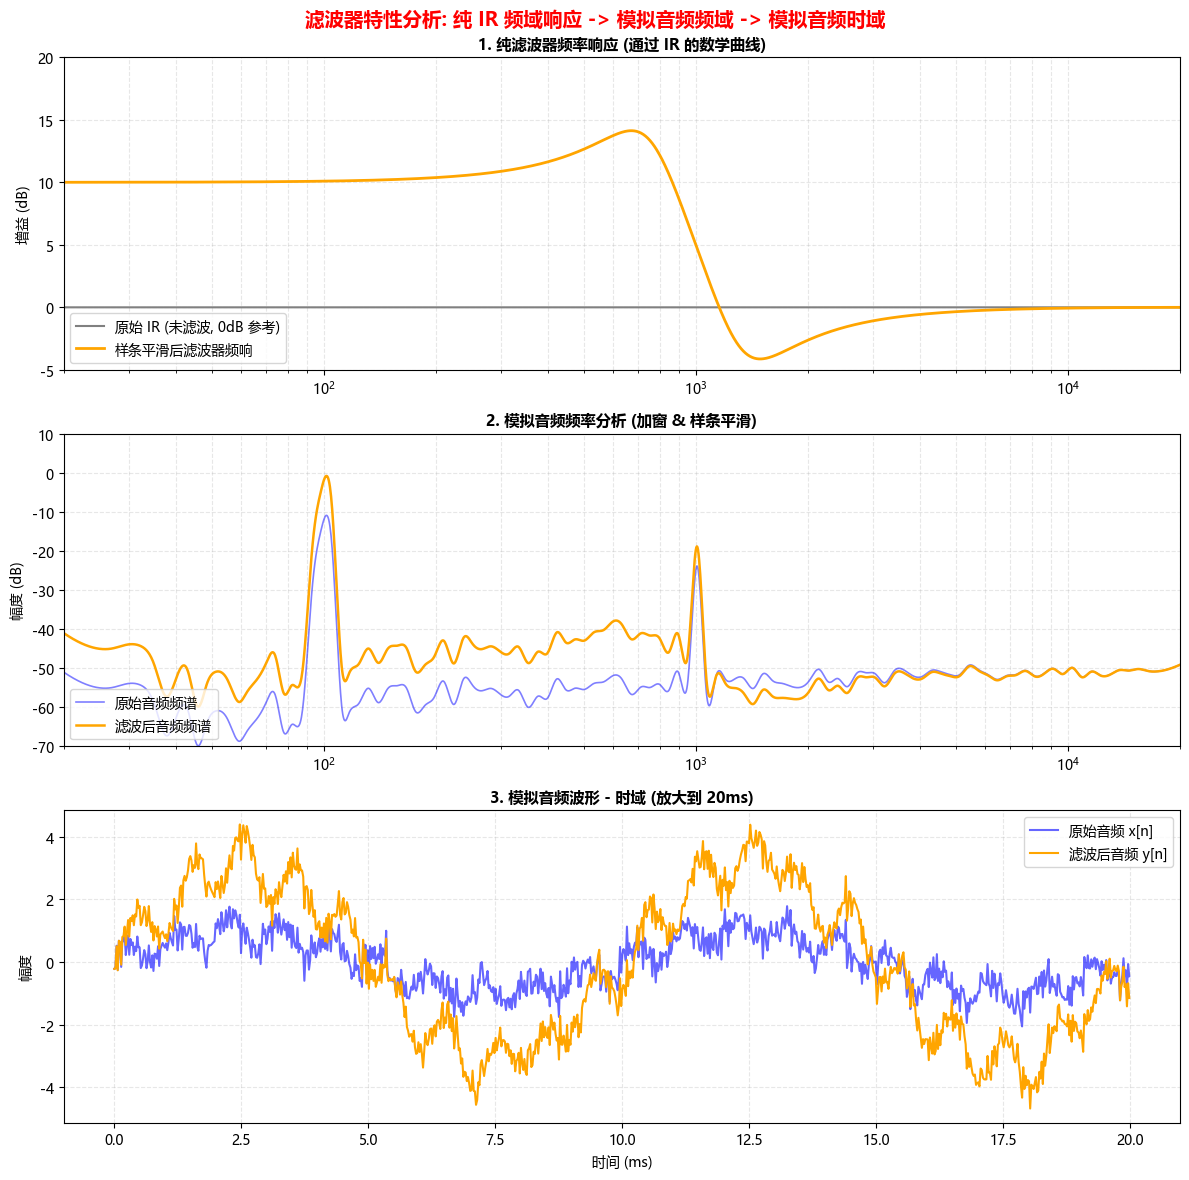

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook High Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    A = 10 ** (gain_db / 40)
    sqrtA = np.sqrt(A)
    
    b0 = A * ((A+1) - (A-1) * np.cos(w0) + 2 * sqrtA * alpha)
    b1 = 2 * A * ((A-1) - (A+1) * np.cos(w0))
    b2 = A * ((A+1) - (A-1) * np.cos(w0) - 2 * sqrtA * alpha) 
    a0 = (A+1) + (A-1) * np.cos(w0) + 2 * sqrtA * alpha
    a1 = -2 * ((A-1) + (A+1)*np.cos(w0))
    a2 = (A+1) + (A-1)*np.cos(w0) - 2 * sqrtA * alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**HIGH_SELF_EQ**

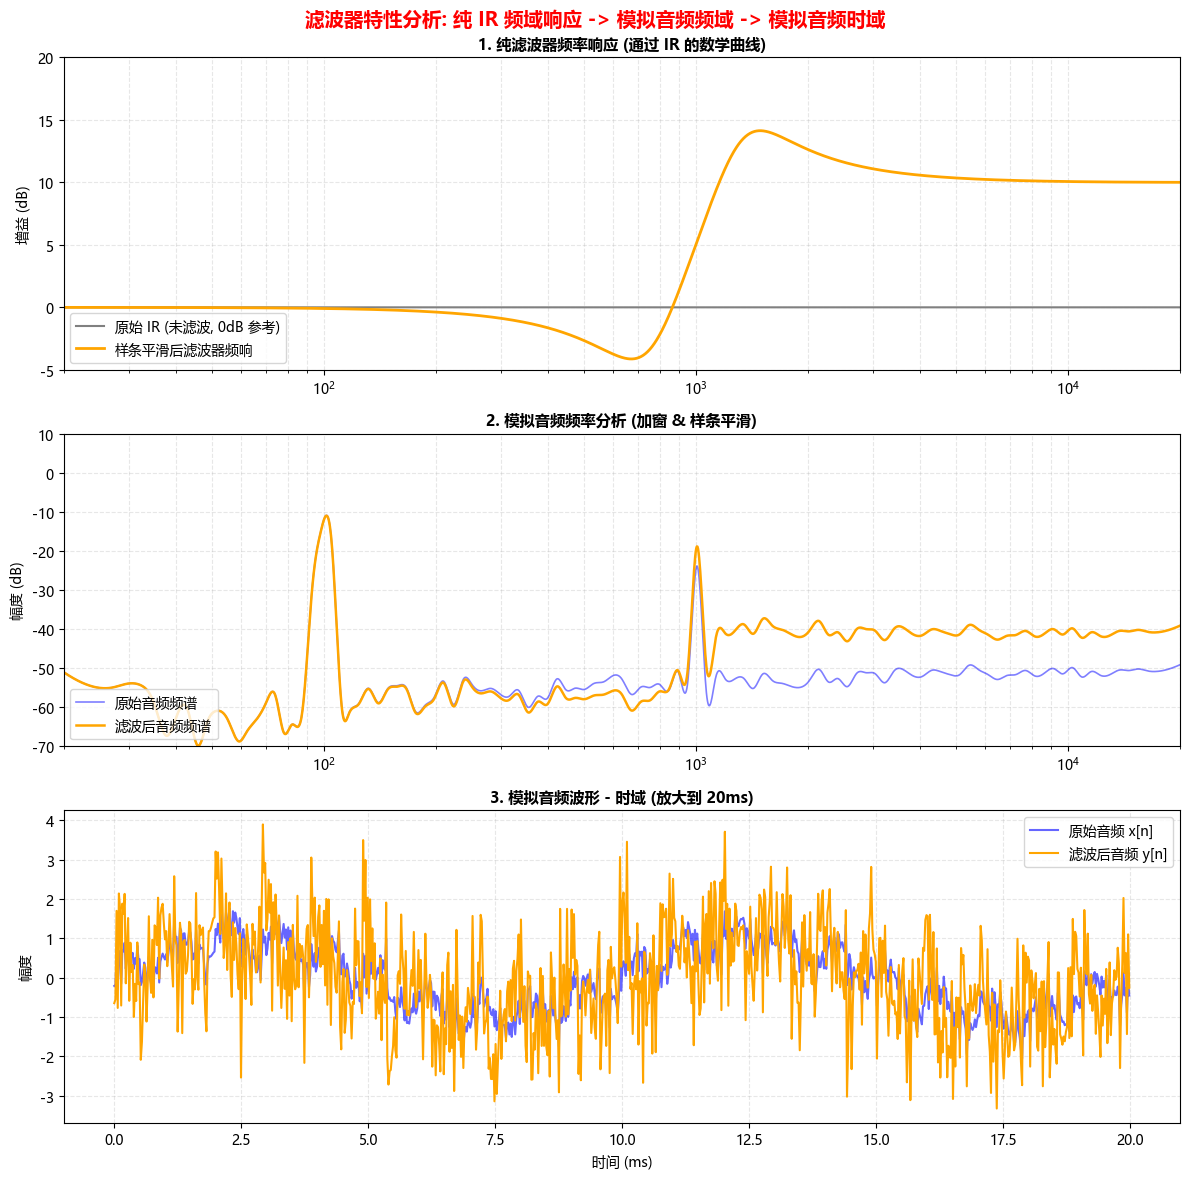

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook HIGH Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    A = 10 ** (gain_db / 40)
    sqrtA = np.sqrt(A)
    
    b0 = A * ((A + 1) + (A - 1) * np.cos(w0) + 2 * sqrtA * alpha)
    b1 = -2 * A * ((A - 1) + (A + 1) * np.cos(w0))
    b2 = A * ((A + 1) + (A - 1) * np.cos(w0) - 2 * sqrtA * alpha)
    a0 = (A + 1) - (A - 1) * np.cos(w0) + 2 * sqrtA * alpha
    a1 = 2 * ((A - 1) - (A + 1) * np.cos(w0))
    a2 = (A + 1) - (A - 1) * np.cos(w0) - 2 * sqrtA * alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

**High SLEF FILTERING**

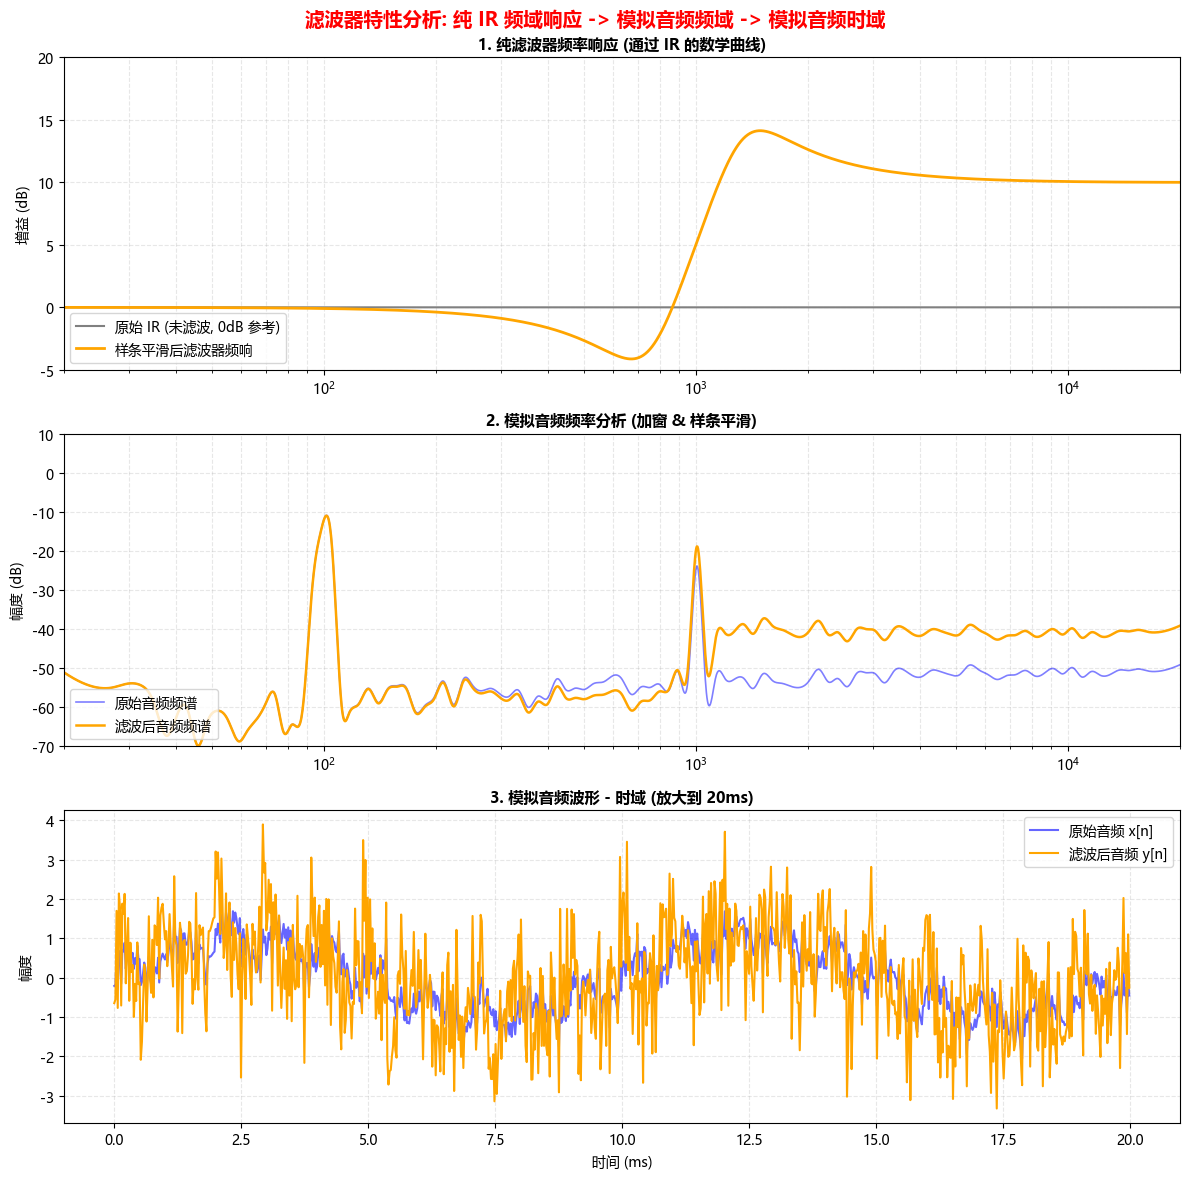

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook LOW Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    A = 10 ** (gain_db / 40)
    sqrtA = np.sqrt(A)
    
    b0 = A * ((A + 1) + (A - 1) * np.cos(w0) + 2 * sqrtA * alpha)
    b1 = -2 * A * ((A - 1) + (A + 1) * np.cos(w0))
    b2 = A * ((A + 1) + (A - 1) * np.cos(w0) - 2 * sqrtA * alpha)
    a0 = (A + 1) - (A - 1) * np.cos(w0) + 2 * sqrtA * alpha
    a1 = 2 * ((A - 1) - (A + 1) * np.cos(w0))
    a2 = (A + 1) - (A - 1) * np.cos(w0) - 2 * sqrtA * alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

***Low Pass Filter***

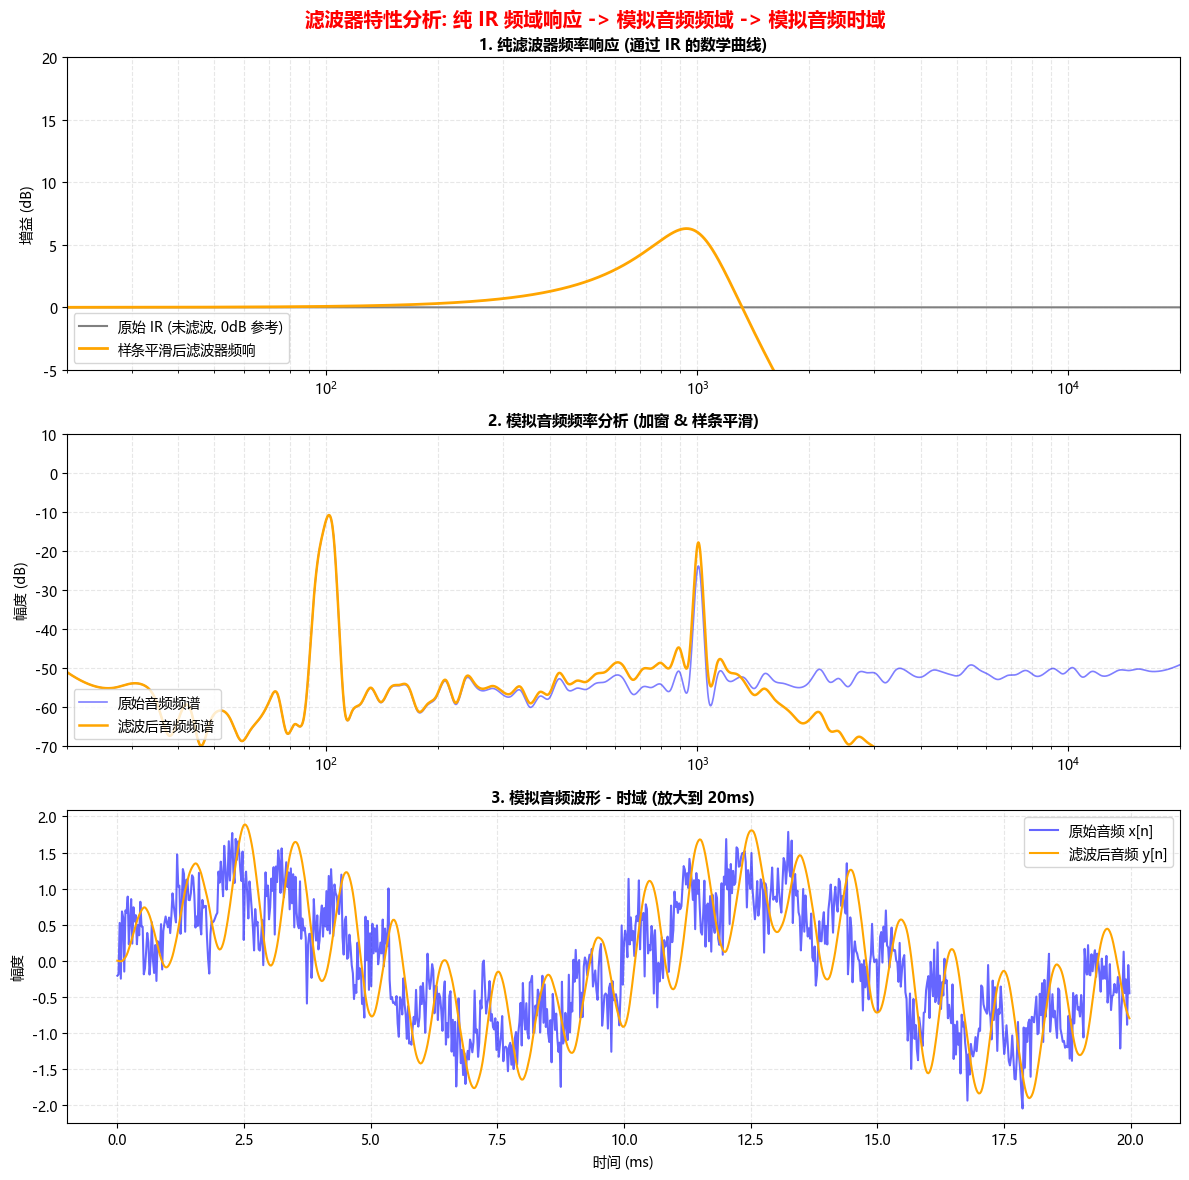

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook LOW Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    
    b0 = (1 - np.cos(w0)) / 2
    b1 = (1 - np.cos(w0))
    b2 = (1 - np.cos(w0)) / 2
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

***High Pass Filter***

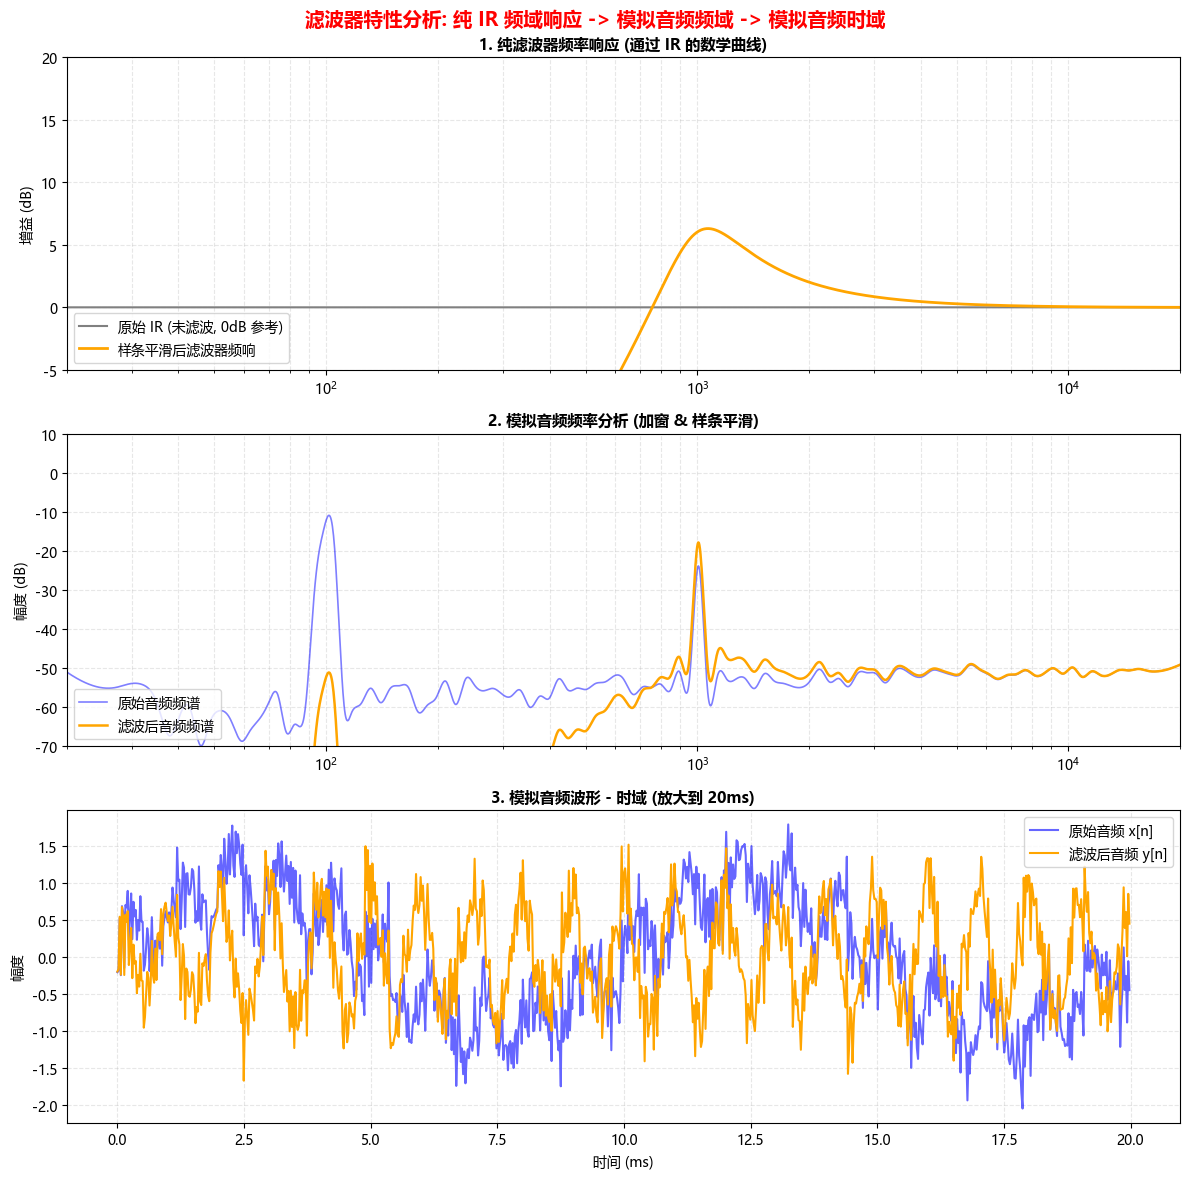

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook LOW Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    
    b0 = (1 + np.cos(w0)) / 2
    b1 = - (1 + np.cos(w0))
    b2 = (1 + np.cos(w0)) / 2
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

***Band Pass Filter***

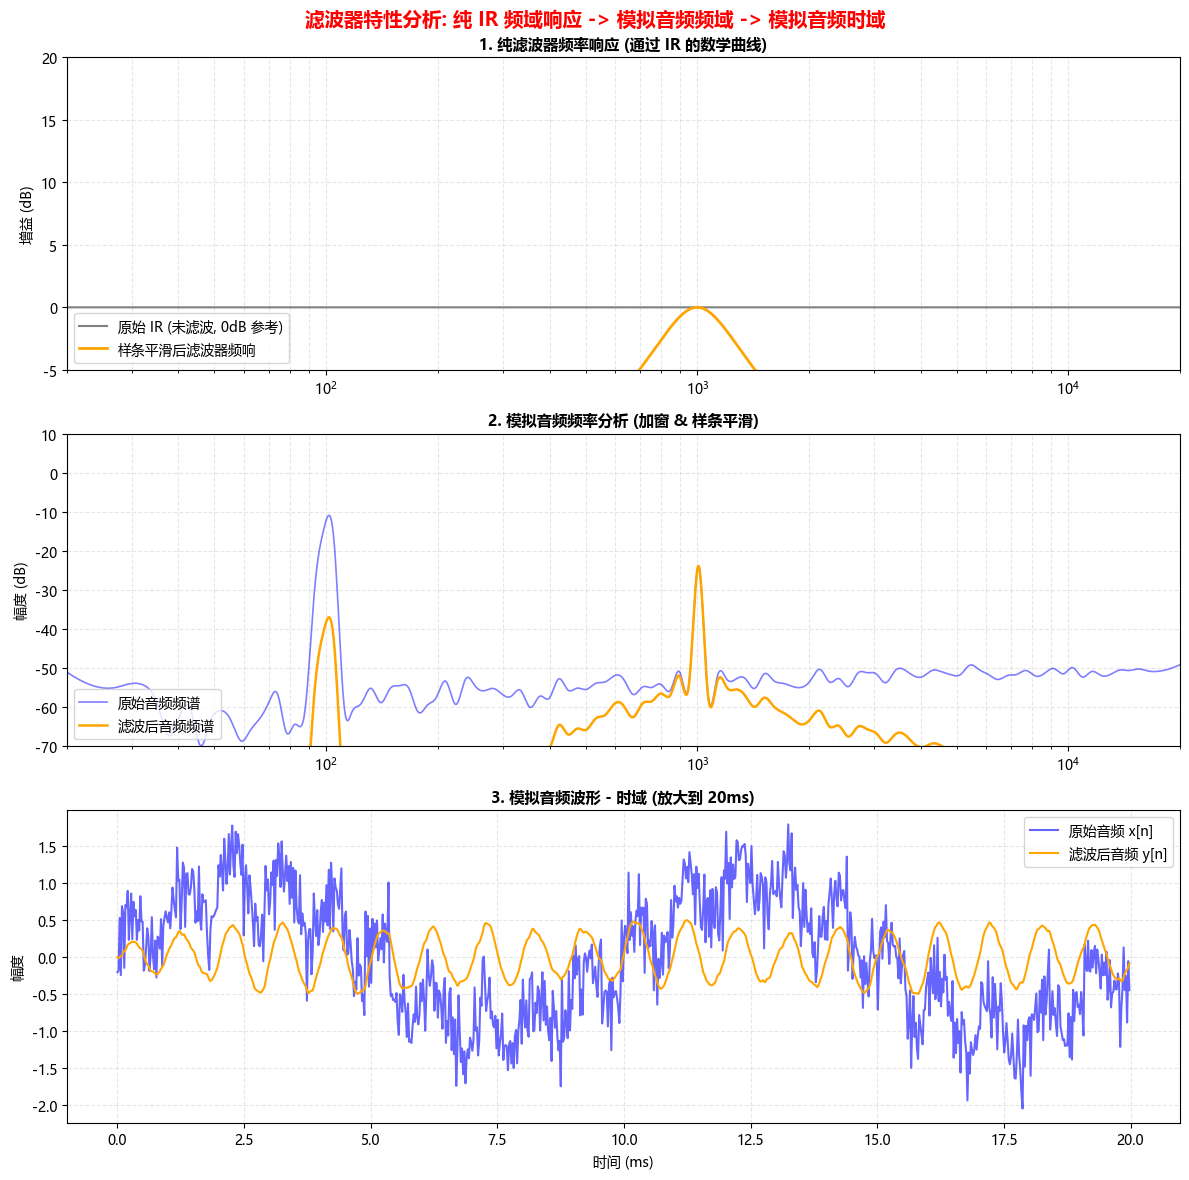

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft
from scipy.signal.windows import blackmanharris
from scipy.interpolate import make_interp_spline
from scipy.signal import lfilter

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

def high_shelf_coefficients(f0, Q, gain_db, fs=44100):
    """RBJ Audio EQ Cookbook LOW Shelf Filter"""
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)
    
    b0 = alpha
    b1 = 0
    b2 = -alpha
    a0 = 1 + alpha
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha
    return [b0 / a0, b1 / a0, b2 / a0], [1, a1 / a0, a2 / a0]

def smooth_audio_spectrum(freqs, amp_db, x_target, num_bins=120):
    log_bins = np.logspace(np.log10(20), np.log10(20000), num_bins)
    bin_freqs = []
    bin_values = []
    
    for i in range(len(log_bins) - 1):
        idx = (freqs >= log_bins[i]) & (freqs < log_bins[i + 1])
        if np.any(idx):
            bin_freqs.append(np.mean(freqs[idx]))
            bin_values.append(np.max(amp_db[idx])) 
            
    spline = make_interp_spline(bin_freqs, bin_values, k=3)
    return spline(x_target)

np.random.seed(250)
N = 8192 * 2
fs = 44100
t = np.arange(N) / fs
audio_raw = (np.random.randn(N) * 0.3 + 
             np.sin(2 * np.pi * 100 * t) * 1.0 + 
             np.sin(2 * np.pi * 1000 * t) * 0.4)
window = blackmanharris(N)
freqs = fft.rfftfreq(N, 1 / fs)
b, a = high_shelf_coefficients(f0=1000, Q=2.0, gain_db=10, fs=fs)
impulse_raw = np.zeros(N)
impulse_raw[0] = 1.0
audio_filtered = lfilter(b, a, audio_raw)
impulse_filtered = lfilter(b, a, impulse_raw)  

fft_audio_in = fft.rfft(audio_raw * window)
fft_audio_out = fft.rfft(audio_filtered * window)
ir_fft = fft.rfft(impulse_filtered)
ir_fft_raw = fft.rfft(impulse_raw)  # 原始未滤波 IR

db_audio_in = 20 * np.log10(np.abs(fft_audio_in) / N + 1e-12)
db_audio_out = 20 * np.log10(np.abs(fft_audio_out) / N + 1e-12)
db_ir = 20 * np.log10(np.abs(ir_fft) + 1e-12)
db_ir_raw = 20 * np.log10(np.abs(ir_fft_raw) + 1e-12)  # 原始 IR = 理论 0dB 平坦

x_smooth = np.logspace(np.log10(20), np.log10(20000), 2000)
y_smooth_audio_in = smooth_audio_spectrum(freqs, db_audio_in, x_smooth)
y_smooth_audio_out = smooth_audio_spectrum(freqs, db_audio_out, x_smooth)
spline_ir = make_interp_spline(freqs[1:], db_ir[1:], k=3)
y_smooth_ir = spline_ir(x_smooth)
spline_ir_raw = make_interp_spline(freqs[1:], db_ir_raw[1:], k=3)
y_smooth_ir_raw = spline_ir_raw(x_smooth)

fig, (ir_ax, freq_ax, time_ax) = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("滤波器特性分析: 纯 IR 频域响应 -> 模拟音频频域 -> 模拟音频时域", fontsize=14, fontweight='bold', color='red')

# 图 1：原始 IR-FFT（密铺蓝线）+ 平滑曲线（粗橙线）对比 + 未滤波 0dB 参考
ir_ax.semilogx(x_smooth, y_smooth_ir_raw, color='gray', linewidth=1.5, linestyle='-', label='原始 IR (未滤波, 0dB 参考)')
ir_ax.semilogx(x_smooth, y_smooth_ir, color='orange', linewidth=2.0, label='样条平滑后滤波器频响')
ir_ax.set_title("1. 纯滤波器频率响应 (通过 IR 的数学曲线)", fontsize=11, fontweight='bold')
ir_ax.set_ylabel("增益 (dB)")
ir_ax.set_xlim(20, 20000)
ir_ax.set_ylim(-5, 20)
ir_ax.grid(True, which='both', alpha=0.3, linestyle='--')
ir_ax.legend(loc='lower left')

# 图 2：加窗平滑后的音频频谱
freq_ax.semilogx(x_smooth, y_smooth_audio_in, color='blue', alpha=0.5, linewidth=1.2, label='原始音频频谱')
freq_ax.semilogx(x_smooth, y_smooth_audio_out, color='orange', linewidth=1.8, label='滤波后音频频谱')
freq_ax.set_title("2. 模拟音频频率分析 (加窗 & 样条平滑)", fontsize=11, fontweight='bold')
freq_ax.set_ylabel("幅度 (dB)")
freq_ax.set_xlim(20, 20000)
freq_ax.set_ylim(-70, 10)
freq_ax.grid(True, which='both', alpha=0.3, linestyle='--')
freq_ax.legend(loc='lower left')

# 图 3：时域波形对比
time_zoom = int(fs * 0.02)
time_ax.plot(t[:time_zoom] * 1000, audio_raw[:time_zoom], color='blue', alpha=0.6, label='原始音频 x[n]')
time_ax.plot(t[:time_zoom] * 1000, audio_filtered[:time_zoom], color='orange', linewidth=1.5, label='滤波后音频 y[n]')
time_ax.set_title("3. 模拟音频波形 - 时域 (放大到 20ms)", fontsize=11, fontweight='bold')
time_ax.set_xlabel("时间 (ms)")
time_ax.set_ylabel("幅度")
time_ax.grid(True, alpha=0.3, linestyle='--')
time_ax.legend(loc='upper right')

plt.tight_layout()
plt.show()